In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import IPython

pd.set_option('display.max_columns', None)

# Data Loading

In [2]:
DATA_PATH = "results/MAG2P_order_parameters-2025-12-8-16:13:13.pickle"

dg = pd.read_pickle(DATA_PATH)
df = dg.fillna(0)
df = df.drop(columns=["std_bonds_1_8", "std_bonds_1_5", "std_size",
                       "std_radius_of_gyration", "std_second_neighbours"])
df = df.loc[:, (df != 0).any(axis=0)]

print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 2760 rows, 87 columns


/tmp/ipykernel_1098365/1699651328.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = dg.fillna(0)


,file_id,lambda,shift,mean_bonds_1_8,mean_bonds_1_5,mean_second_neighbours,mean_size,largest,mean_radius_of_gyration,0.125664,0.251327,0.376991,0.502655,0.628319,0.753982,0.879646,1.00531,1.130973,1.256637,1.382301,1.507964,1.633628,1.759292,1.884956,2.010619,2.136283,2.261947,2.38761,2.513274,2.638938,2.764602,2.890265,3.015929,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,1.1,1.3,1.5,1.7,1.9,2.1,2.3,2.5,2.7,2.9,3.1,3.3,3.5,3.7,3.9,4.1,4.3,4.5,4.7,4.9,5.1,5.3,5.5,5.7,5.9
0,mag2p_shift_0.15_lambda_30_phi2d_0.0106_rid_1/,30.0,0.15,1.726,1.726,0.0,7.587786,32,3.503756,3.476328,1.364712,0.184421,0.009221,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.155463,0.416339,0.766414,1.229084,1.816968,2.479134,3.263851,4.112634,5.120903,5.905970,7.207076,8.649195,9.855037,9.300543,12.406700,12.112959,0.000000,18.315904,0.000000,0.000000,24.949207,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,123.785408,0.0,0.000000,0.000000,0.000000,0.394341,23.738146,0.000000,0.000000,0.000000,0.036207,9.713634,0.000000,0.000000,0.000000,0.041404,0.451716,3.875424,0.000000,0.014495,0.033451,0.086729,2.209009,0.010712,0.000000
1,mag2p_shift_0.35_lambda_40_phi2d_0.0106_rid_8/,40.0,0.35,1.740,1.740,0.0,6.847222,27,2.792470,2.945281,1.271410,0.466489,0.192084,0.219524,0.182937,0.164643,0.064028,0.118909,0.164643,0.027441,0.009147,0.009147,0.027441,0.036587,0.009147,0.009147,0.018294,0.000000,0.009147,0.000000,0.000000,0.000000,0.000000,0.156924,0.418694,0.785033,0.454389,0.589194,2.448045,1.069686,4.082124,5.121499,5.917206,6.880607,8.575021,9.170284,0.000000,11.239750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,26.61778,0.0,0.0,0.0,124.789459,0.0,0.077235,1.082712,1.685773,3.509636,19.694113,0.278309,0.835182,0.724000,0.380175,8.275761,0.042609,0.152515,0.022879,0.062106,0.856378,2.655224,0.023632,0.014495,0.033451,0.198237,1.622241,0.005356,0.019996
2,mag2p_shift_0.5_lambda_25_phi2d_0.0106_rid_8/,25.0,0.50,2.244,2.244,0.0,5.824561,21,1.081621,0.014185,0.014185,0.014185,0.000000,0.021277,0.000000,0.170219,0.524843,0.290791,0.170219,0.234051,0.290791,0.397178,0.290791,0.801449,2.014260,1.141887,0.461010,0.226959,0.276606,0.170219,0.219866,0.156034,0.056740,0.160079,0.416049,0.445913,0.813668,1.313734,1.427460,0.934960,1.150697,1.383118,1.352940,4.576868,1.607531,0.000000,8.573242,5.781242,0.000000,0.000000,0.000000,0.000000,7.810187,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,160.935379,0.0,8.186895,3.127833,4.383009,16.049683,9.830617,1.196729,1.049943,1.282515,2.534503,4.313620,0.284063,0.393996,0.366070,0.879839,0.846968,0.524170,0.110282,0.239167,0.133805,0.328331,0.310642,0.069629,0.089984
3,mag2p_shift_0.65_lambda_50_phi2d_0.0106_rid_7/,50.0,0.65,1.714,1.714,0.0,6.104294,18,2.350347,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046428,0.510707,0.139284,0.000000,0.000000,0.000000,0.009286,0.204283,2.367824,4.679935,0.154667,0.414145,0.769728,1.228363,1.792840,2.451360,2.700541,3.556798,5.077178,6.158384,7.291809,8.621044,5.867224,11.408399,12.953466,12.297338,16.589534,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,122.924782,0.0,0.000000,0.000000,0.096330,3.075861,19.924259,0.000000,0.047725,0.124114,0.398279,8.084044,0.014203,0.012710,0.125837,0.165617,0.489359,2.895827,0.015755,0.108712,0.066903,0.099119,1.627993,0.032136,0.074987
4,mag2p_shift_0.6_lambda_35_phi2d_0.0106_rid_3/,35.0,0.60,1.754,1.754,0.0,5.818713,23,1.876992,0.009074,0.009074,0.000000,0.000000,0.000000,0.000000,0.036295,0.045369,0.045369,0.000000,0.027221,0.072591,0.009074,0.009074,0.145181,0.671463,0.326658,0.000000,0.000000,0.018148,0.099812,0.943678,2.622336,2.867330,0.154442,0.415638,0.778697,1.234867,1.817944,2.483886,1.491917,2.756248,2.193381,4.298783,0.000000,6.543127,7.

# Feature Groups & Test Sets

In [3]:
# Define named feature groups by column index ranges
# Columns 0-2: file_id, lambda, shift (not features)
# Columns 3-8: global structural measures
# Columns 9-32: orientation (24 angular bins)
# Columns 33-61: radius of gyration (29 bins)
# Columns 62-86: g(r) (25 radial distance bins)

FEATURE_GROUPS = {
    "global":      df.columns[3:9],
    "orientation": df.columns[9:33],
    "Rg":          df.columns[33:62],
    "gofr":        df.columns[62:],
}

# Define test sets: name -> list of groups to KEEP
TEST_SETS = {
    "all_features":        list(FEATURE_GROUPS.keys()),
    "no_functions":        ["global"],
    "no_orientation_Rg":   ["global", "gofr"],
    "no_orientation_gofr": ["global", "Rg"],
    "no_Rg_gofr":          ["global", "orientation"],
    "no_global_Rg":        ["orientation", "gofr"],
    "no_orientation":      ["global", "Rg", "gofr"],
    "no_Rg":               ["global", "orientation", "gofr"],
}

# Print summary
for name, groups in TEST_SETS.items():
    n_cols = sum(len(FEATURE_GROUPS[g]) for g in groups)
    print(f"{name:25s} -> {groups}  ({n_cols} features)")

all_features              -> ['global', 'orientation', 'Rg', 'gofr']  (84 features)
no_functions              -> ['global']  (6 features)
no_orientation_Rg         -> ['global', 'gofr']  (31 features)
no_orientation_gofr       -> ['global', 'Rg']  (35 features)
no_Rg_gofr                -> ['global', 'orientation']  (30 features)
no_global_Rg              -> ['orientation', 'gofr']  (49 features)
no_orientation            -> ['global', 'Rg', 'gofr']  (60 features)
no_Rg                     -> ['global', 'orientation', 'gofr']  (55 features)


# Spectral Embedding: Diffusion Heatmap

In [4]:
import hdbscan
import seaborn as sns
import cmasher as cmr
from sklearn.manifold import SpectralEmbedding
from matplotlib.colors import ListedColormap, rgb2hex


def run_diffusion_heatmap(X, lambdas, shifts, set_name, cluster_min_size=10):
    """
    Perform Diffusion Maps on data X, assign clusters with HDBSCAN,
    and create heatmaps over (shift, lambda) space.
    Outputs are saved with set_name suffix.
    """
    embedding = SpectralEmbedding(
        n_components=2, affinity='nearest_neighbors', n_neighbors=32
    )
    diffmap_emb = embedding.fit_transform(X)
    cluster_labels = hdbscan.HDBSCAN(
        min_cluster_size=cluster_min_size, core_dist_n_jobs=-1
    ).fit_predict(diffmap_emb)

    df_cluster = pd.DataFrame({
        'lambda': lambdas,
        'shift': shifts,
        'cluster': cluster_labels,
        'Diff-1': diffmap_emb[:, 0],
        'Diff-2': diffmap_emb[:, 1],
    })

    # Color map: distinct colors for clusters, gray for noise
    unique_clusters = sorted(df_cluster['cluster'].unique())
    non_noise = [cl for cl in unique_clusters if cl != -1]
    palette = cmr.chroma(np.linspace(0, 1, max(len(non_noise), 1)))
    hex_colors = [rgb2hex(c) for c in palette]
    color_map = {str(cl): hex_colors[i] for i, cl in enumerate(non_noise)}
    color_map['-1'] = '#A0A0A0'

    # Diffusion Map scatter
    fig = px.scatter(
        df_cluster, x='Diff-1', y='Diff-2',
        color=df_cluster['cluster'].astype(str),
        hover_data={'lambda': True, 'shift': True},
        title=f'Diffusion Map - {set_name}',
        color_discrete_map=color_map,
    )
    fig.write_html(f'diffmap_clusters_{set_name}.html')
    fig.show()

    # Discrete cluster heatmap
    heatmap_data = df_cluster.groupby(['lambda', 'shift'])['cluster'] \
                             .agg(lambda x: x.value_counts().idxmax()) \
                             .unstack().sort_index(ascending=False)

    unique_hm = sorted(heatmap_data.stack().dropna().unique())
    non_noise_hm = [cl for cl in unique_hm if cl != -1]
    colors = cmr.chroma(np.linspace(0, 1, max(len(non_noise_hm), 1)))
    colors_hex = [rgb2hex(c) for c in colors]
    colors_all = ['#A0A0A0' if cl == -1 else colors_hex.pop(0) for cl in unique_hm]
    cmap = ListedColormap(colors_all)

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap=cmap, annot=False, cbar=True,
                linewidths=0.5, linecolor='gray')
    plt.title(f'HDBSCAN Clusters - {set_name}')
    plt.xlabel('shift')
    plt.ylabel('lambda')
    plt.tight_layout()
    plt.savefig(f'heatmap_diffmap_{set_name}.pdf')
    plt.show()

    # Continuous Diff-1 heatmap
    cont_data = df_cluster.groupby(['lambda', 'shift'])['Diff-1'] \
                          .mean().unstack().sort_index(ascending=False)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cont_data, cmap=cmr.chroma, annot=False, cbar=True,
                linewidths=0.5, linecolor='gray')
    plt.title(f'Average Diff-1 - {set_name}')
    plt.xlabel('shift')
    plt.ylabel('lambda')
    plt.tight_layout()
    plt.savefig(f'heatmap_diffmap_continuous_{set_name}.pdf')
    plt.show()

    return df_cluster

# Run All Test Sets


Running: all_features (groups: ['global', 'orientation', 'Rg', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


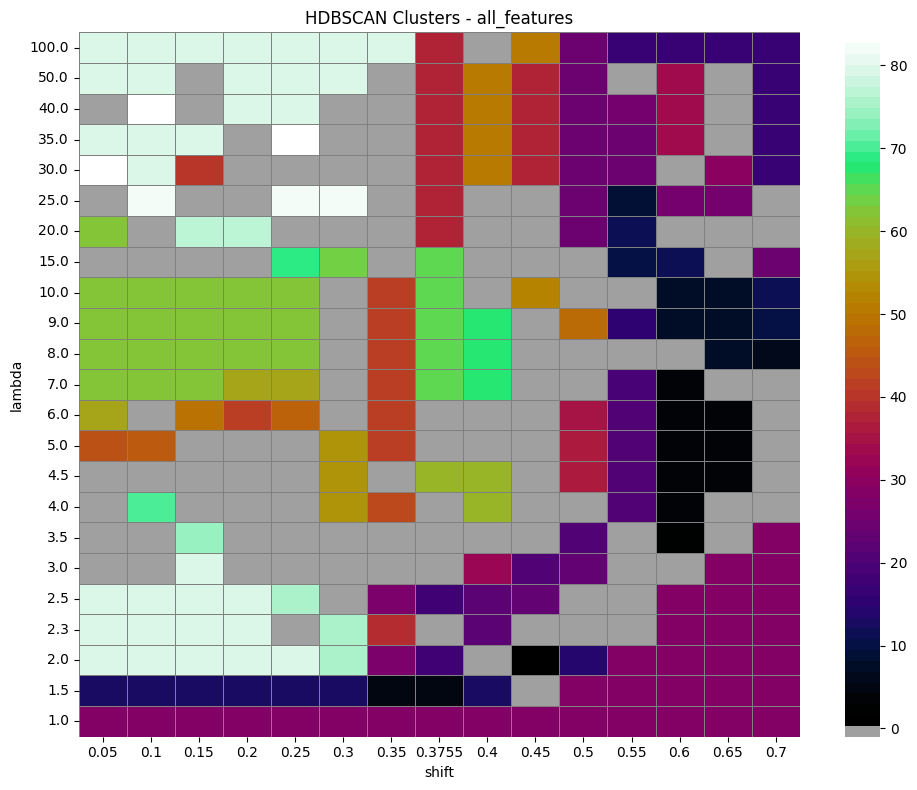

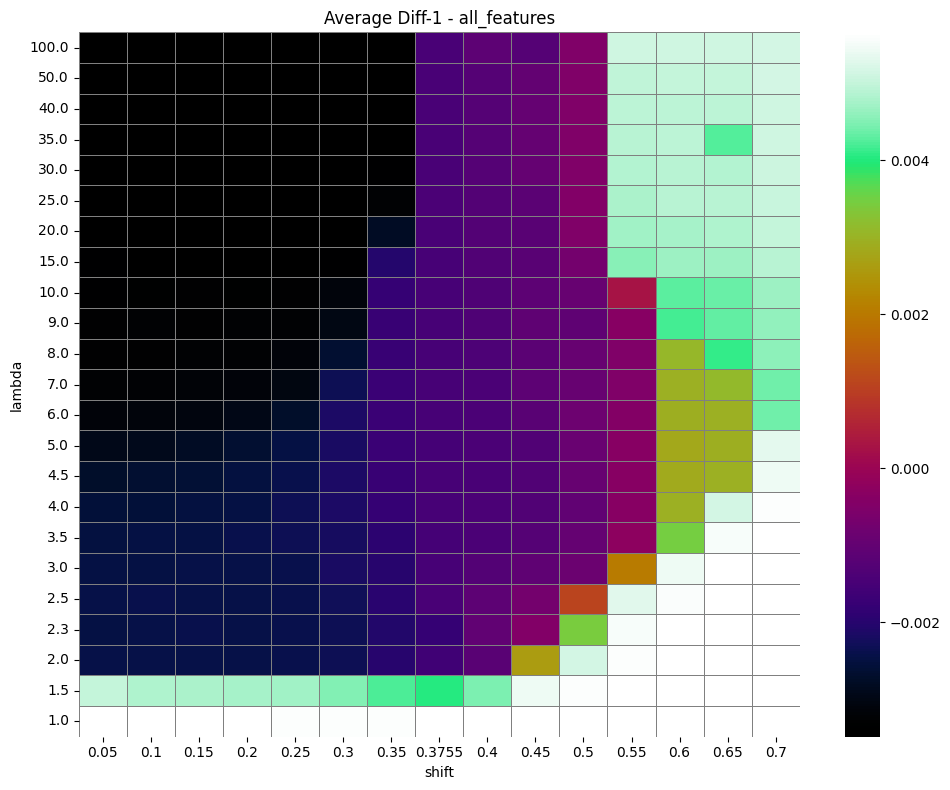


Running: no_functions (groups: ['global'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



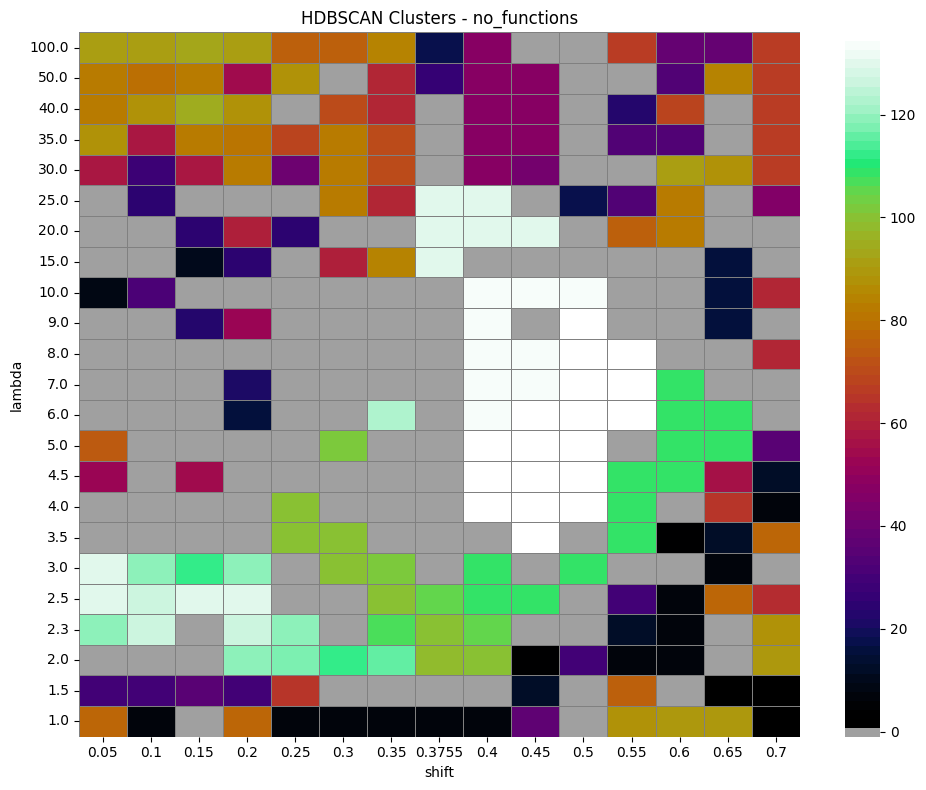

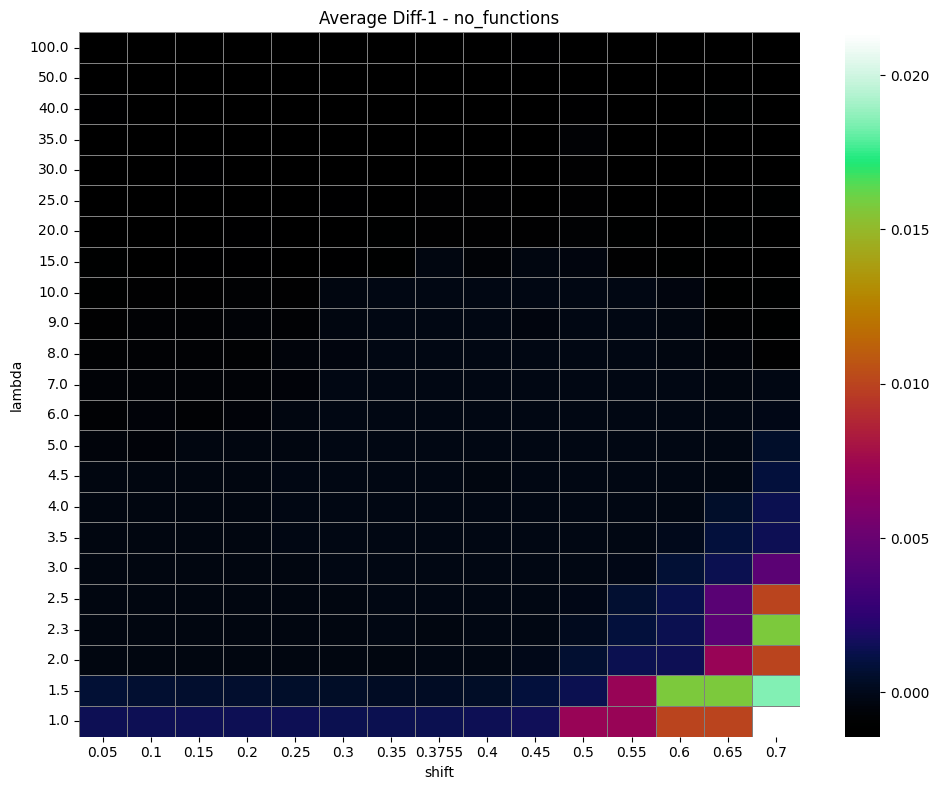


Running: no_orientation_Rg (groups: ['global', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



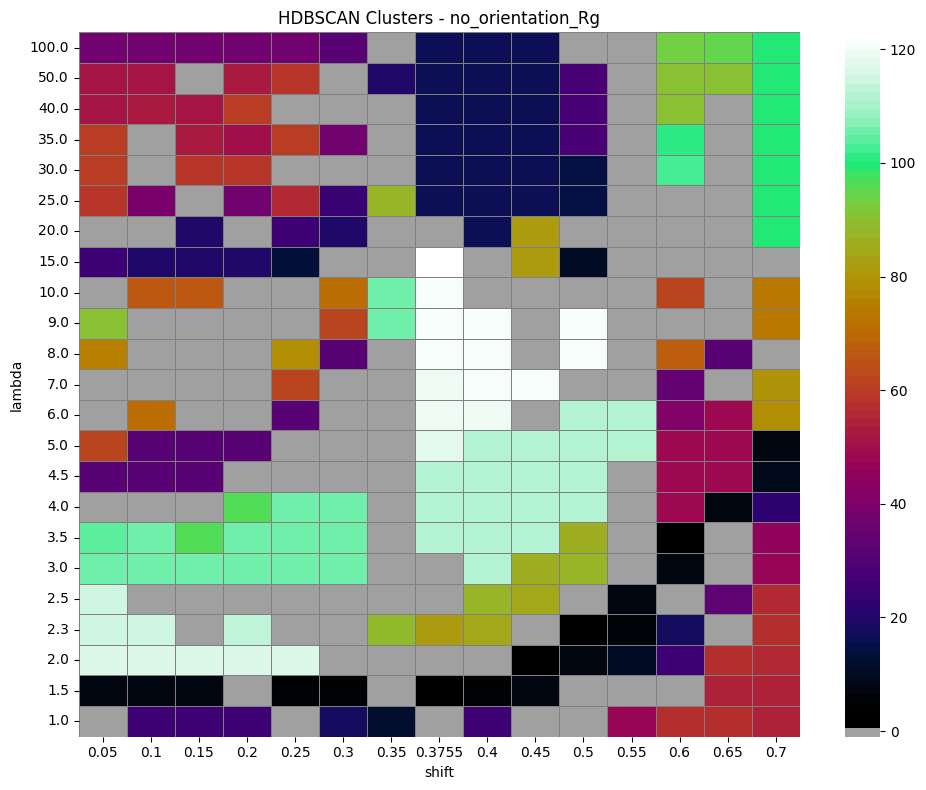

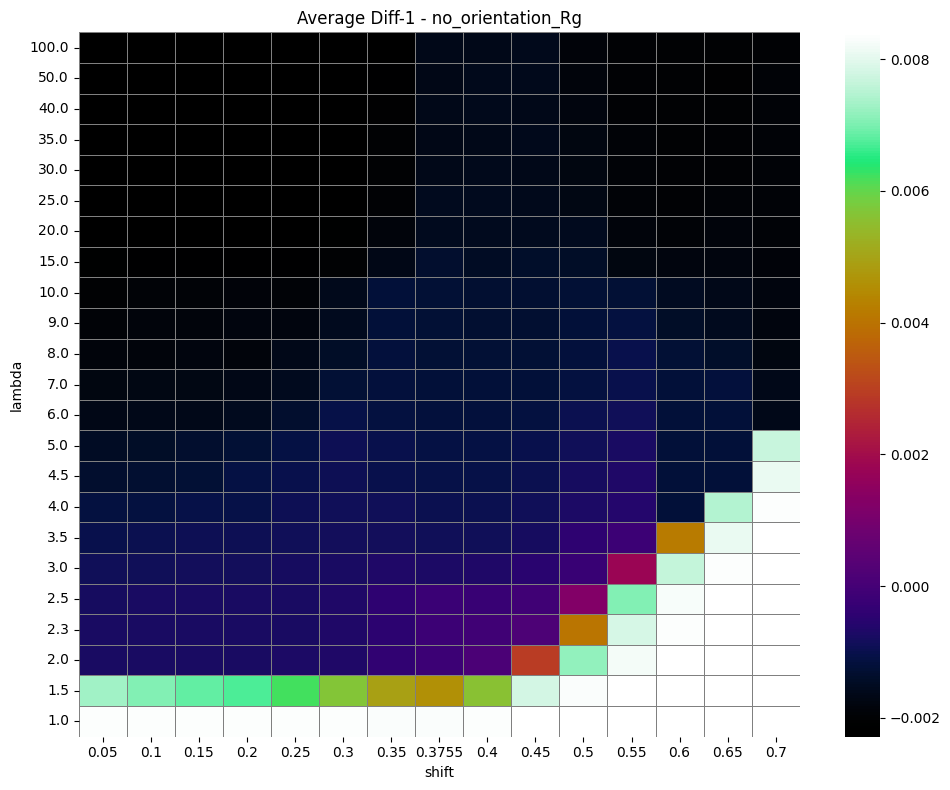


Running: no_orientation_gofr (groups: ['global', 'Rg'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



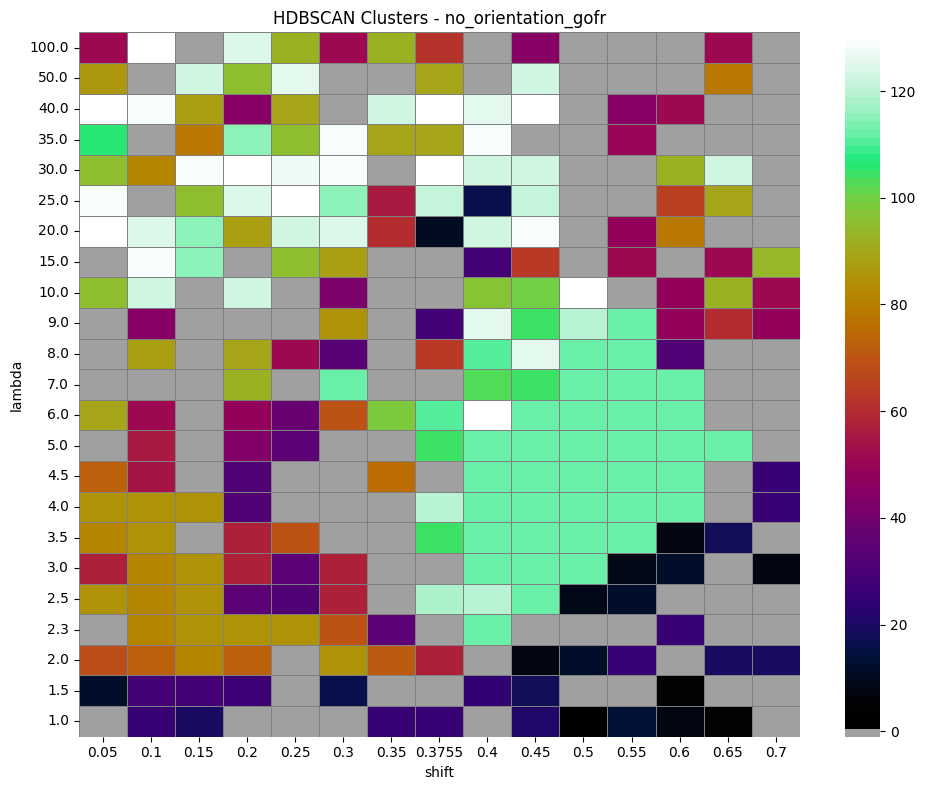

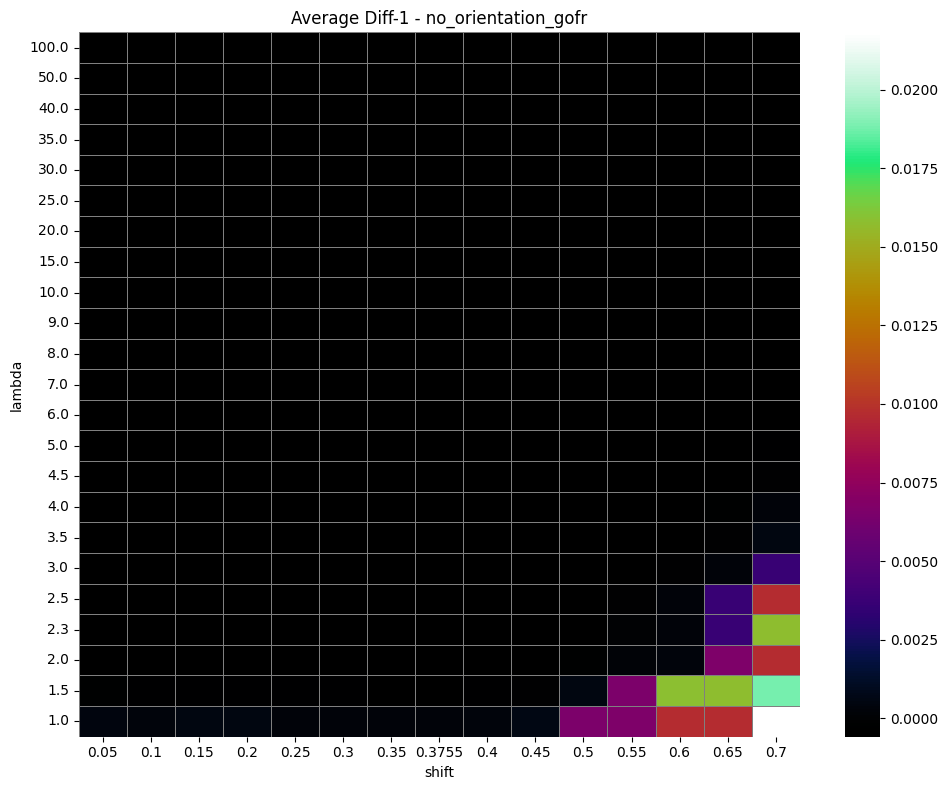


Running: no_Rg_gofr (groups: ['global', 'orientation'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



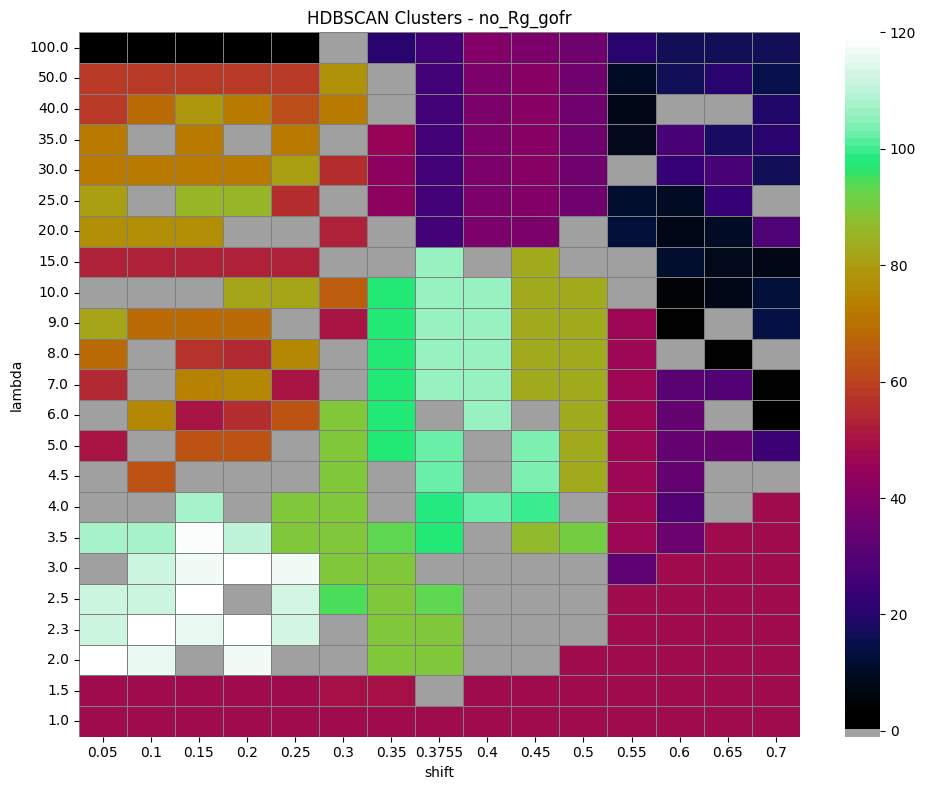

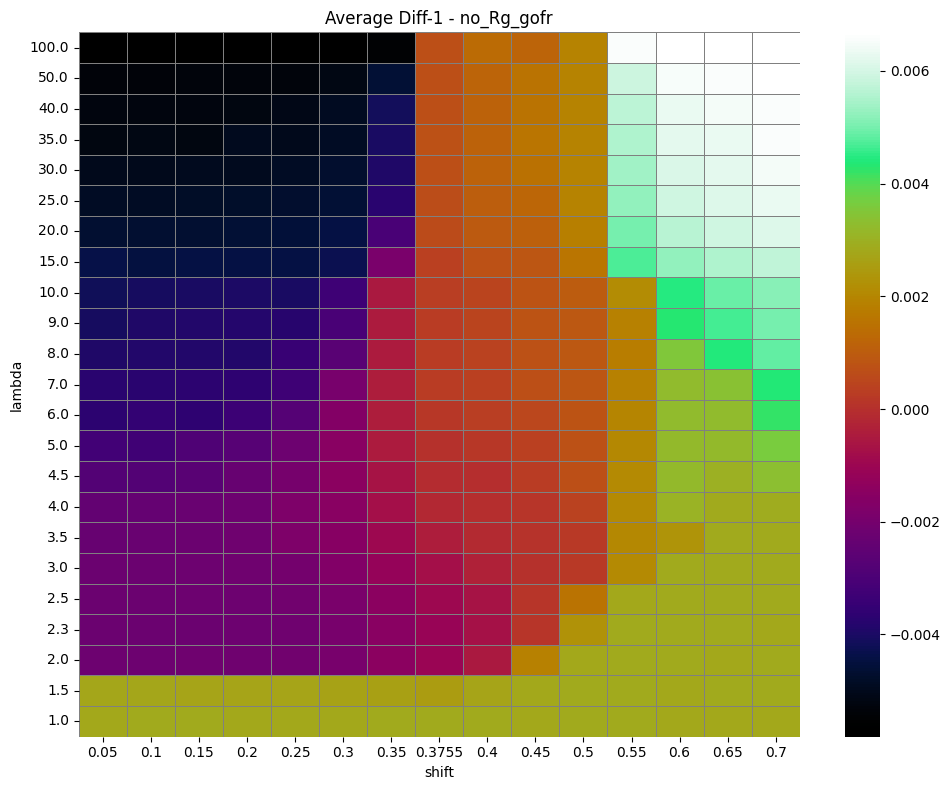


Running: no_global_Rg (groups: ['orientation', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



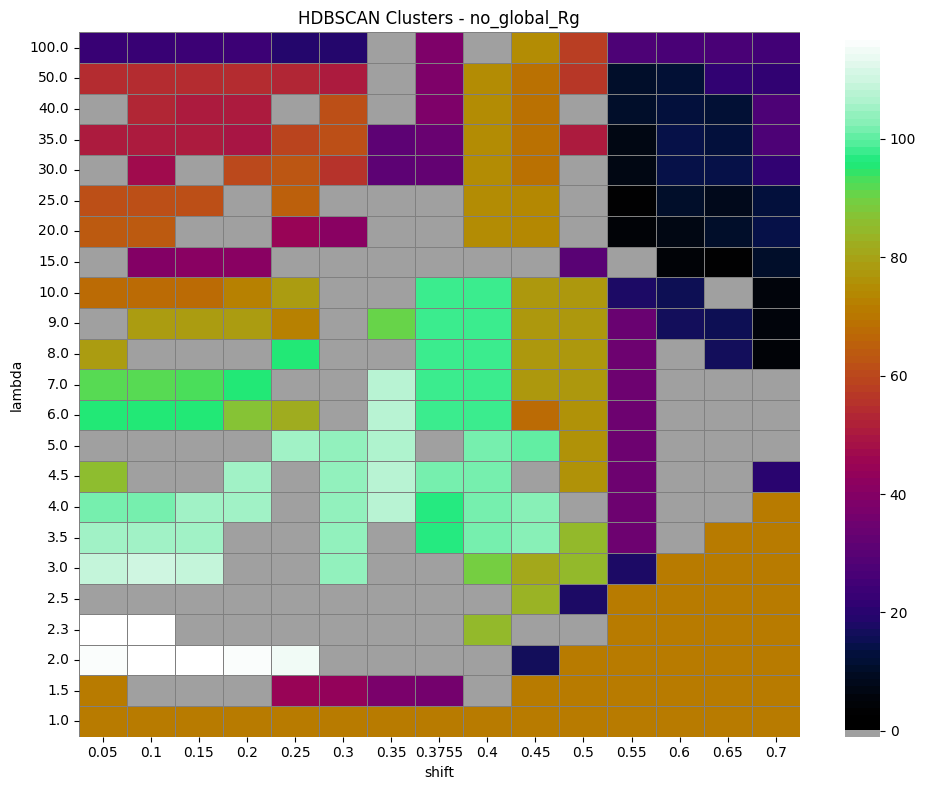

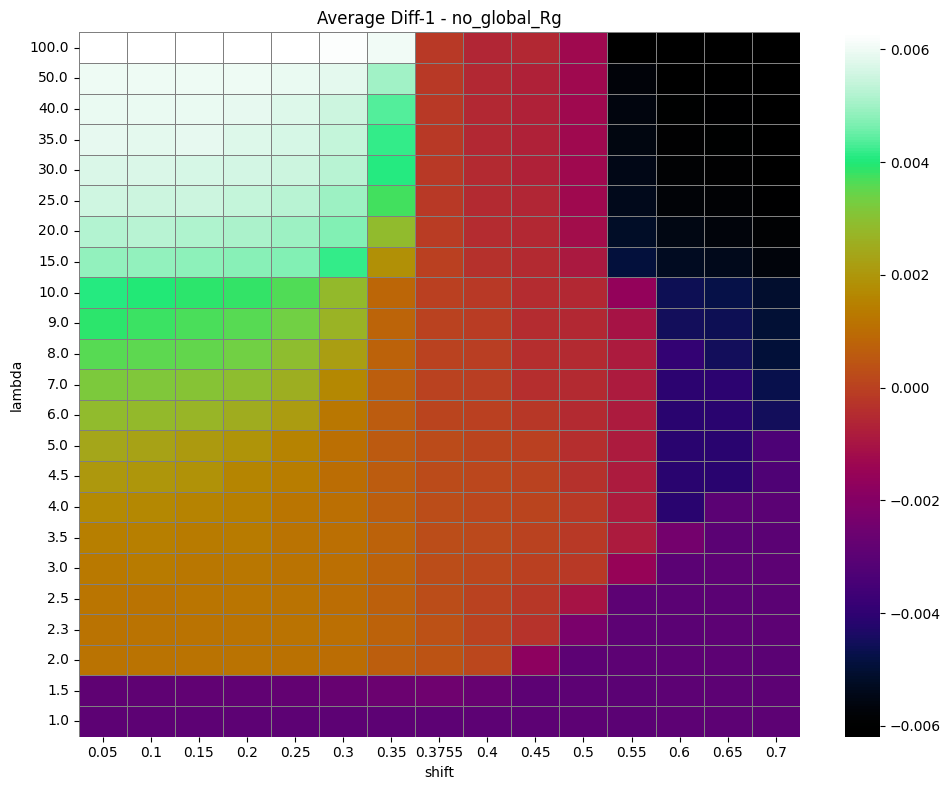


Running: no_orientation (groups: ['global', 'Rg', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



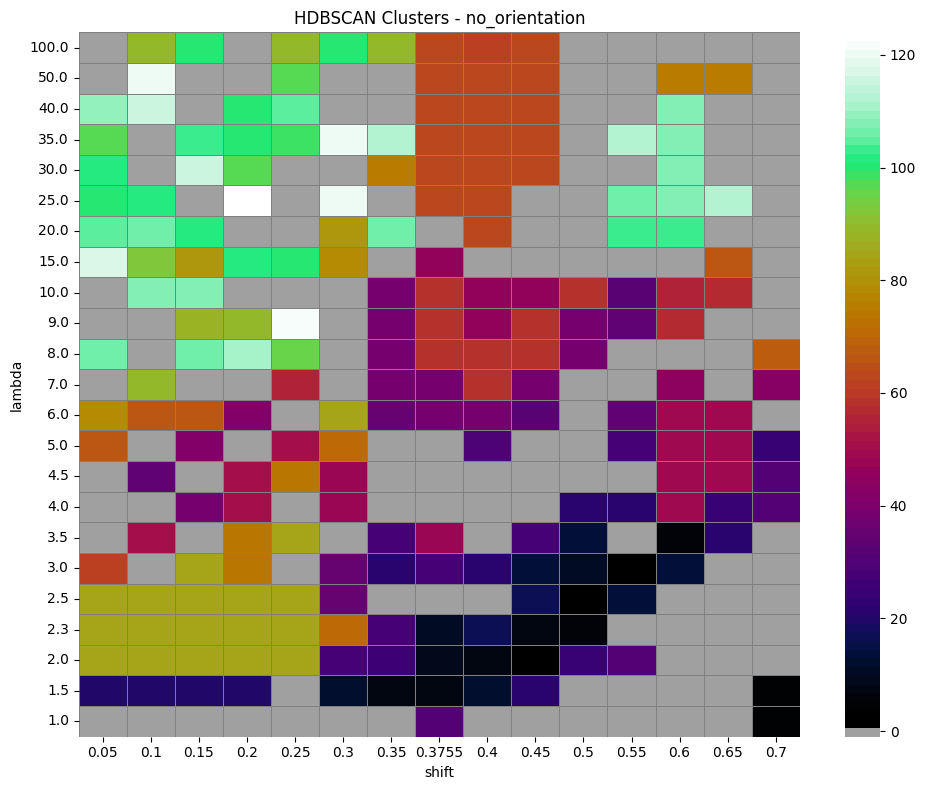

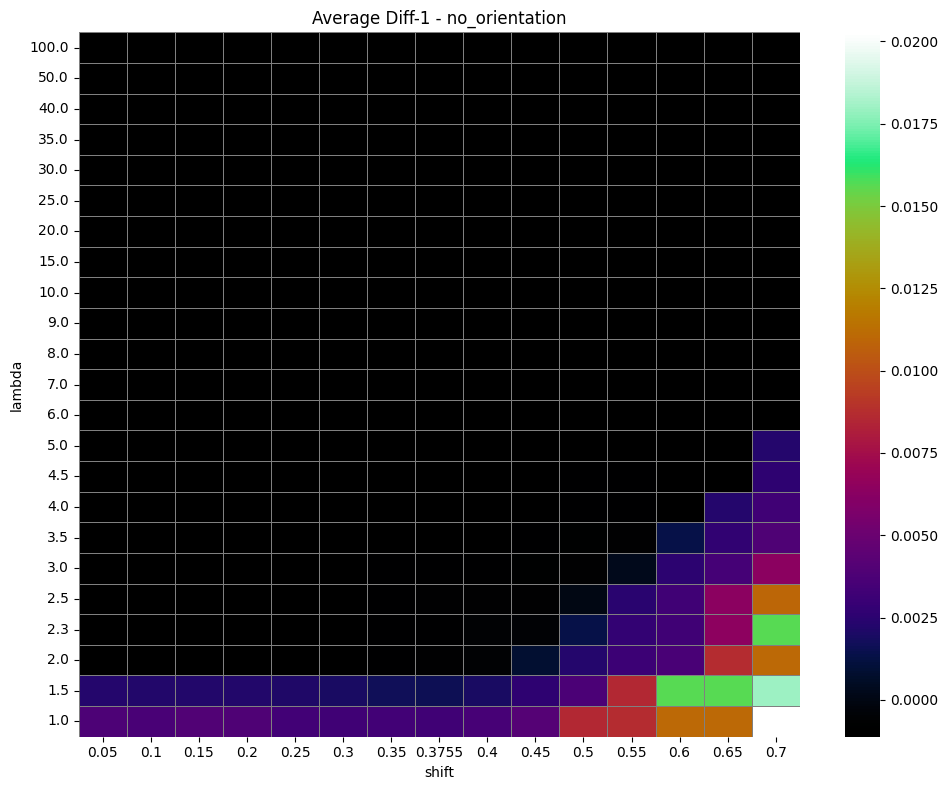


Running: no_Rg (groups: ['global', 'orientation', 'gofr'])


/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/karner/.local/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



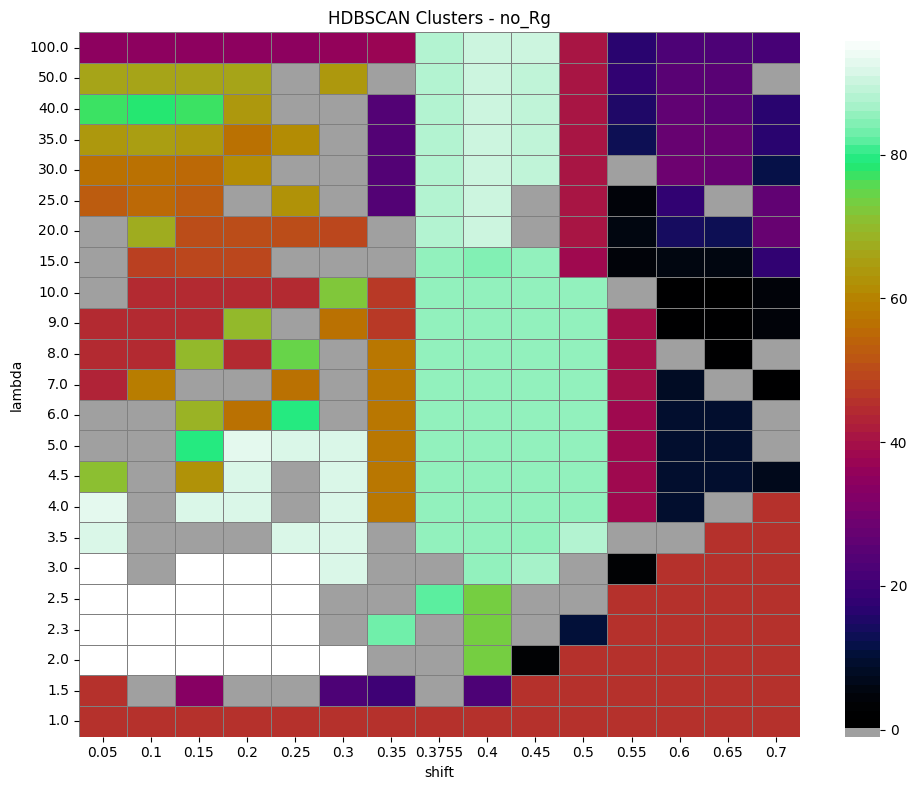

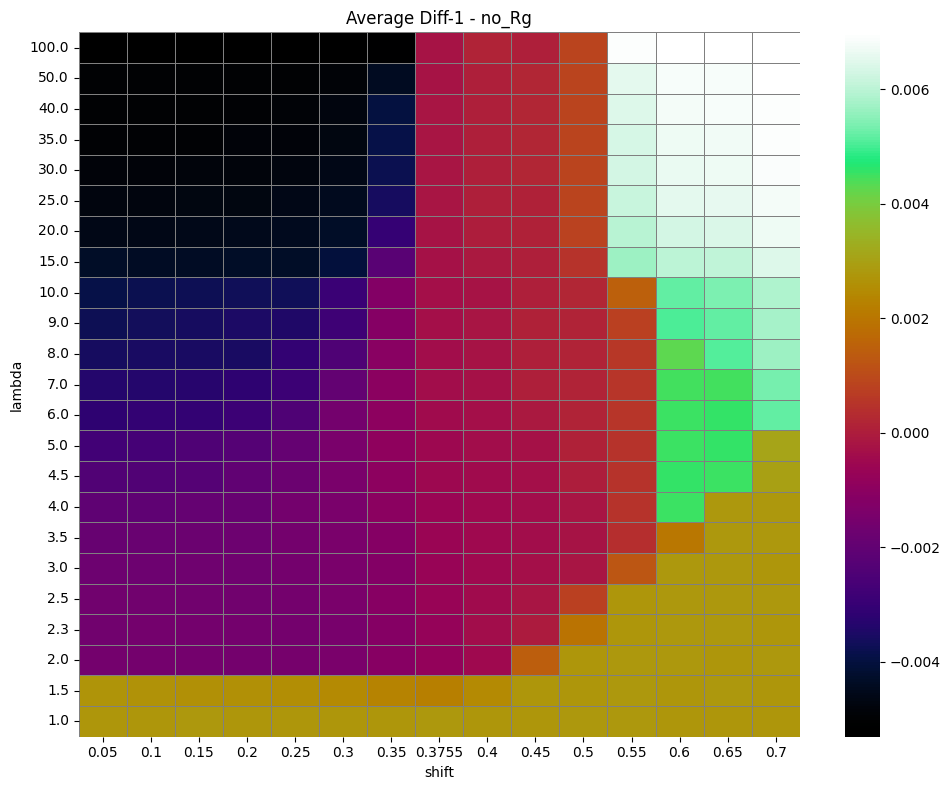

In [5]:
from sklearn.preprocessing import StandardScaler

Shift = df['shift']
Lambda = df['lambda']

results = {}
for name, keep_groups in TEST_SETS.items():
    print(f'\n{"="*60}')
    print(f'Running: {name} (groups: {keep_groups})')
    print(f'{"="*60}')

    feature_cols = [c for g in keep_groups for c in FEATURE_GROUPS[g]]
    X = df[feature_cols].values
    X = StandardScaler().fit_transform(X)

    results[name] = run_diffusion_heatmap(X, Lambda, Shift, set_name=name, cluster_min_size=5)

# Spectral Embedding: All Features vs Reduced Features

Compares the geometry learned from the full descriptor space against
a reduced space with all global scalar descriptors (mean bonds, mean
size, largest cluster, mean radius of gyration, mean second neighbours)
**and** radius-of-gyration bins removed.

Uses eigenvalues of the graph Laplacian to characterise the spectral
gap across neighbourhood sizes. Interactive scatter plots and
cross-embedding coordinate matching are included.


In [6]:
import json
import os
import random
import warnings
from datetime import datetime

import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.linalg import subspace_angles
from scipy.optimize import linear_sum_assignment
from scipy.sparse.csgraph import connected_components, laplacian
from scipy.sparse.linalg import eigsh
from scipy.spatial import procrustes
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr, spearmanr
from sklearn.manifold import SpectralEmbedding
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.preprocessing import StandardScaler

# Execution configuration. GRAPH_K_VALUES remains the available sweep.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N_COMPONENTS = 10
N_COMPONENTS_TO_ANALYZE = 5
N_MATCHED_COMPONENTS = 3
GRAPH_K_VALUES = [5, 10, 20, 32, 50]
RUN_K_VALUES = [32]

SHIFT_MIN, SHIFT_MAX = 0.0, 0.7
LAMBDA_MIN, LAMBDA_MAX = 0.0, 30.0
TICK_FONT = 14
TITLE_FONT = 16
MISSING_CELL_COLOR = "#bdbdbd"

TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S-%f")
RESULTS_DIR = os.path.join("results", f"spectral_{TIMESTAMP}")
RESULT_DIRS = {
    name: os.path.join(RESULTS_DIR, name)
    for name in ["diagnostics", "scatters", "state_diagrams", "differences", "data"]
}
for directory in [RESULTS_DIR, *RESULT_DIRS.values()]:
    os.makedirs(directory, exist_ok=False)
print(f"Results directory: {os.path.abspath(RESULTS_DIR)}")


def cmasher_to_plotly_colorscale(cmap, n=256):
    xs = np.linspace(0, 1, n)
    return [
        [float(x), f"rgba({int(r * 255)},{int(g * 255)},{int(b * 255)},{a:.3f})"]
        for x, (r, g, b, a) in ((x, cmap(x)) for x in xs)
    ]

DIVERGING_COLORSCALE = cmasher_to_plotly_colorscale(cmr.guppy)


Results directory: /home/karner/Documents/github/MagneticParticles/rigid_magnetic/results/spectral_20260724-173736-557302


## Feature sets


In [7]:
# ── Build feature matrices ────────────────────────────────────────────
# Reduced set drops global scalars and radius-of-gyration bins.
FEATURE_SETS = {
    "all_features": ["global", "orientation", "Rg", "gofr"],
    "reduced_no_global": ["orientation", "gofr"],
}

X_dict = {}
cols_dict = {}
row_metadata = {}
sample_metadata = df[["file_id", "lambda", "shift"]].reset_index(drop=True).copy()

for fs_name, groups in FEATURE_SETS.items():
    cols = []
    for group in groups:
        cols.extend(FEATURE_GROUPS[group])
    cols = list(dict.fromkeys(cols))
    assert len(cols) == len(set(cols)), f"Duplicate columns in {fs_name}"

    # Every feature set is constructed from this unchanged dataframe order.
    X_dict[fs_name] = StandardScaler().fit_transform(df[cols].to_numpy())
    cols_dict[fs_name] = cols
    row_metadata[fs_name] = sample_metadata.copy()
    print(f"{fs_name}: {len(cols)} features, {len(X_dict[fs_name])} configurations")

removed = sorted(
    set(cols_dict["all_features"]) - set(cols_dict["reduced_no_global"]),
    key=lambda column: list(df.columns).index(column),
)
print(f"Columns removed from reduced set ({len(removed)}):")
print(removed)


all_features: 84 features, 2760 configurations
reduced_no_global: 49 features, 2760 configurations
Columns removed from reduced set (35):
['mean_bonds_1_8', 'mean_bonds_1_5', 'mean_second_neighbours', 'mean_size', 'largest', 'mean_radius_of_gyration', np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


## Sample alignment


In [8]:
# ── Assert sample alignment ───────────────────────────────────────────
all_rows = row_metadata["all_features"]
reduced_rows = row_metadata["reduced_no_global"]
assert X_dict["all_features"].shape[0] == X_dict["reduced_no_global"].shape[0]
assert all_rows.equals(reduced_rows), "Feature sets do not have identical row metadata"
assert all_rows.equals(sample_metadata), "Feature-set row order changed from the source dataframe"
assert not all_rows.duplicated().all(), "Sample metadata is unexpectedly entirely duplicated"
Shift = sample_metadata["shift"]
Lambda = sample_metadata["lambda"]
print(f"Alignment verified: {len(sample_metadata)} configurations in identical dataframe order")


Alignment verified: 2760 configurations in identical dataframe order


## Spectral embeddings and graph construction

Each symmetrised kNN graph is constructed **once** and passed directly
to `sklearn.manifold.spectral_embedding`. The same adjacency matrix is
used for connectivity diagnostics and Laplacian eigenvalues.


In [9]:
graphs = {}
embeddings = {}
eigenvalues = {}

for fs_name, X in X_dict.items():
    for k in GRAPH_K_VALUES:
        key = (fs_name, k)
        graph = kneighbors_graph(X, n_neighbors=k, mode="connectivity", include_self=True)
        graph = 0.5 * (graph + graph.T)
        graphs[key] = graph
        if k in RUN_K_VALUES:
            embeddings[key] = SpectralEmbedding(
                n_components=N_COMPONENTS,
                affinity="precomputed",
                random_state=SEED,
            ).fit_transform(graph)

        n_graph_components, _ = connected_components(graph, directed=False)
        n_eigenvalues = n_graph_components + N_COMPONENTS
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            evals, _ = eigsh(
                laplacian(graph, normed=True),
                k=n_eigenvalues,
                which="SM",
                v0=np.random.default_rng(SEED + k).standard_normal(graph.shape[0]),
            )
        eigenvalues[key] = np.sort(evals)
        print(f"{fs_name:25s} k={k:3d} eigenvalues={n_eigenvalues:3d}")


all_features              k=  5 eigenvalues= 13


all_features              k= 10 eigenvalues= 11


all_features              k= 20 eigenvalues= 11


all_features              k= 32 eigenvalues= 11


all_features              k= 50 eigenvalues= 11


reduced_no_global         k=  5 eigenvalues= 36


reduced_no_global         k= 10 eigenvalues= 12


reduced_no_global         k= 20 eigenvalues= 11


reduced_no_global         k= 32 eigenvalues= 11


reduced_no_global         k= 50 eigenvalues= 11


## Graph connectivity diagnostics


In [10]:
conn_rows = []
for fs_name in X_dict:
    for k in RUN_K_VALUES:
        graph = graphs[(fs_name, k)]
        n_comp, labels = connected_components(graph, directed=False)
        sizes = np.bincount(labels)
        conn_rows.append({
            "feature_set": fs_name,
            "k": k,
            "n_components": n_comp,
            "largest_component": int(sizes.max()),
            "fraction_in_largest": float(sizes.max() / graph.shape[0]),
        })
connectivity_df = pd.DataFrame(conn_rows)
display(connectivity_df)


,feature_set,k,n_components,largest_component,fraction_in_largest
0,all_features,32,1,2760,1.0
1,reduced_no_global,32,1,2760,1.0


## Spectral gap: eigenvalues of the graph Laplacian

One zero eigenvalue corresponds to each connected component. For
disconnected graphs the leading "trivial" eigenvalues encode component
structure, not smooth directions. These are shaded in red below.


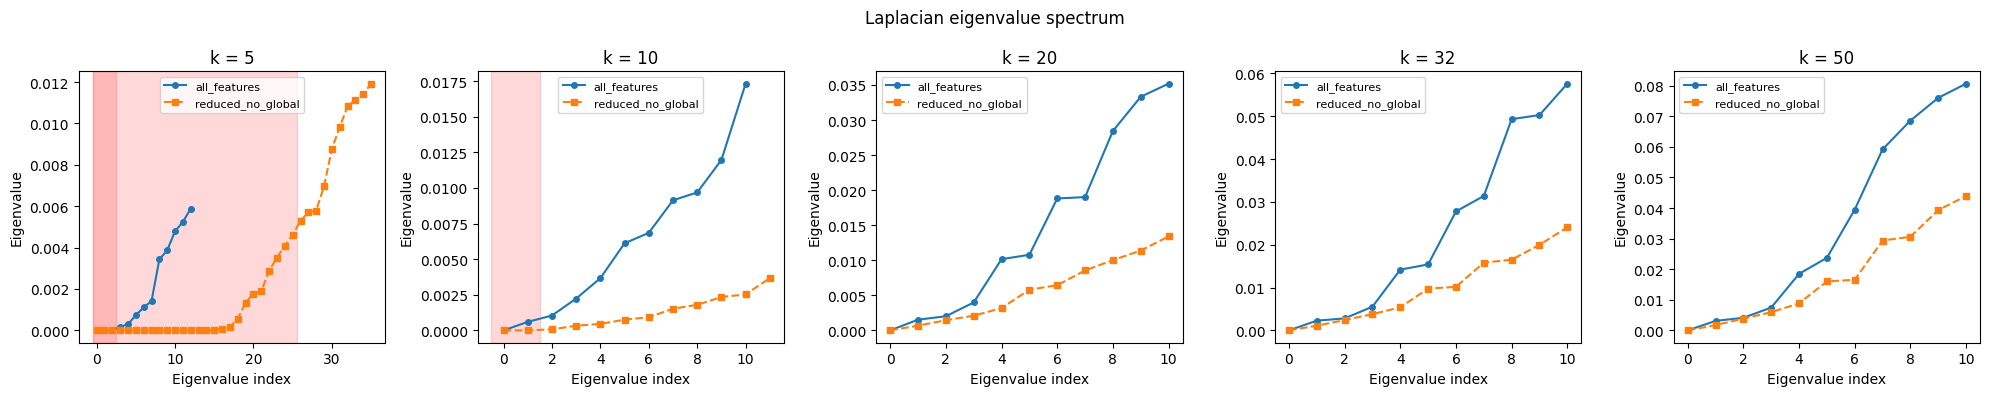

In [11]:
fig, axes = plt.subplots(1, len(GRAPH_K_VALUES), figsize=(4 * len(GRAPH_K_VALUES), 4), sharey=False)
axes = np.atleast_1d(axes)
spectrum_rows = []
for ax, k in zip(axes, GRAPH_K_VALUES):
    for fs_name, style in [("all_features", "-o"), ("reduced_no_global", "--s")]:
        evals = eigenvalues[(fs_name, k)]
        n_comp, _ = connected_components(graphs[(fs_name, k)], directed=False)
        ax.plot(np.arange(len(evals)), evals, style, markersize=4, label=fs_name)
        if n_comp > 1:
            ax.axvspan(-0.5, n_comp - 0.5, alpha=0.15, color="red")
        spectrum_rows.extend({"feature_set": fs_name, "k": k, "eigenvalue_index": i, "eigenvalue": value}
                             for i, value in enumerate(evals))
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Eigenvalue index")
    ax.set_ylabel("Eigenvalue")
    ax.legend(fontsize=8)
fig.suptitle("Laplacian eigenvalue spectrum")
fig.tight_layout()
fig.savefig(os.path.join(RESULT_DIRS["diagnostics"], "laplacian_spectrum.pdf"), bbox_inches="tight")
plt.show()
spectrum_df = pd.DataFrame(spectrum_rows)


## Component heatmaps (state-diagram style)

Each cell uses the state-diagram (shift, λ*) grid and cell boundaries.
Mean maps compare the first three full components with their matched,
sign-aligned reduced components; standard-deviation maps use matched scales.

In [12]:
def state_stat_table(values):
    return (
        pd.DataFrame({"lambda": Lambda.to_numpy(), "shift": Shift.to_numpy(), "value": values})
        .groupby(["lambda", "shift"])["value"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )


STATE_SHIFTS = np.sort(sample_metadata["shift"].unique())
STATE_LAMBDAS = np.sort(sample_metadata.loc[sample_metadata["lambda"] <= LAMBDA_MAX, "lambda"].unique())


def state_grid(table, column):
    visible = table.loc[table["lambda"] <= LAMBDA_MAX]
    return (
        visible.pivot(index="lambda", columns="shift", values=column)
        .reindex(index=STATE_LAMBDAS, columns=STATE_SHIFTS)
    )


def heatmap_trace(grid, colorscale, zmin, zmax, title, showscale=True, text=None):
    return go.Heatmap(
        x=grid.columns.to_numpy(),
        y=grid.index.to_numpy(),
        z=grid.to_numpy(),
        text=None if text is None else text.to_numpy(),
        texttemplate=None if text is None else "%{text:.0f}",
        zmin=zmin,
        zmax=zmax,
        colorscale=colorscale,
        showscale=showscale,
        hoverongaps=False,
        colorbar=dict(title=title, thickness=18) if showscale else None,
        hovertemplate="shift=%{x}<br>λ*=%{y}<br>value=%{z:.5g}<extra></extra>",
    )


def style_state_figure(fig, width, height):
    fig.update_xaxes(title_text="shift", tickfont=dict(size=TICK_FONT), title_font=dict(size=TITLE_FONT))
    fig.update_yaxes(title_text="λ*", tickfont=dict(size=TICK_FONT), title_font=dict(size=TITLE_FONT))
    fig.update_annotations(font=dict(size=TITLE_FONT))
    fig.update_layout(
        template="plotly_white",
        width=width,
        height=height,
        margin=dict(l=70, r=70, t=70, b=55),
        plot_bgcolor=MISSING_CELL_COLOR,
    )
    return fig


heatmap_stats = {}
for fs_name in X_dict:
    for k in RUN_K_VALUES:
        for component in range(N_COMPONENTS_TO_ANALYZE):
            heatmap_stats[(fs_name, k, component)] = state_stat_table(
                embeddings[(fs_name, k)][:, component]
            )


## Cross-embedding component matching

For each graph k, the first five coordinates from the all-feature and
reduced-feature embeddings are compared. The Hungarian algorithm
maximises absolute Pearson correlation to obtain a one-to-one component
matching.


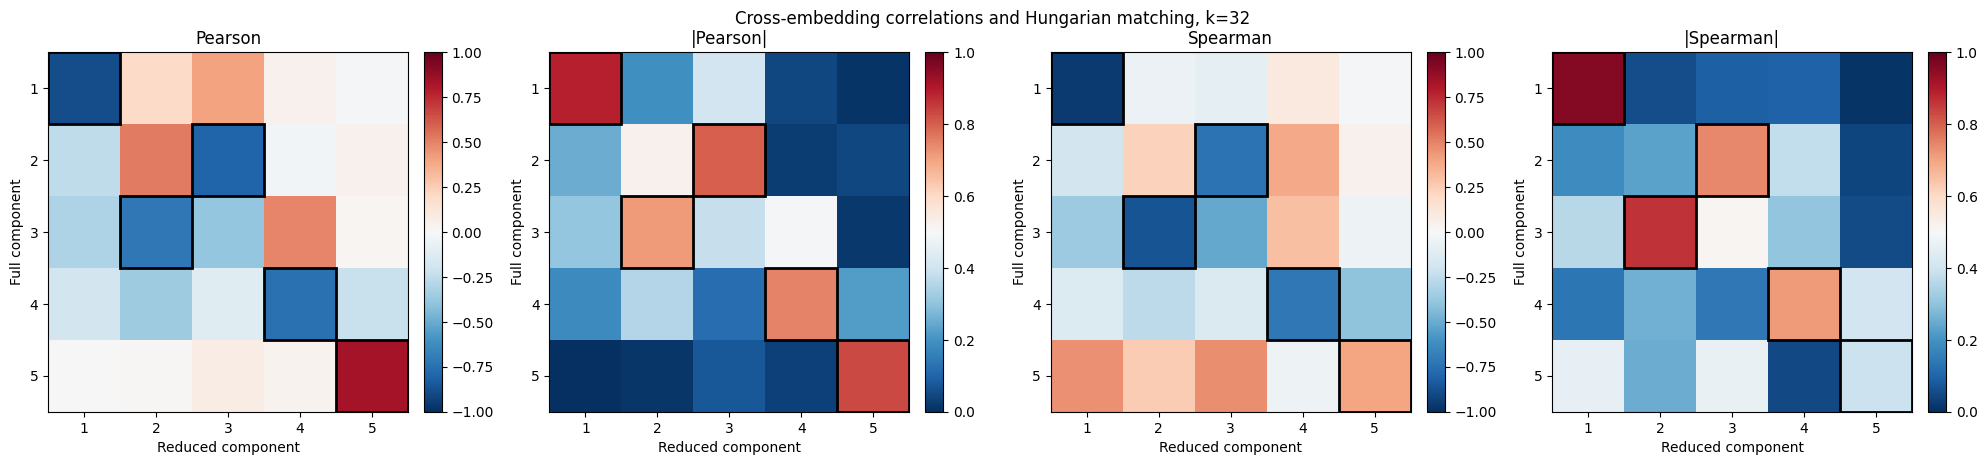

,k,all_feature_comp,reduced_comp,pearson_r,abs_pearson,spearman_r,abs_spearman,sign
0,32,1,1,-0.889978,0.889978,-0.957189,0.957189,-1
1,32,2,3,-0.800718,0.800718,-0.741925,0.741925,-1
2,32,3,2,-0.712492,0.712492,-0.861684,0.861684,-1
3,32,4,4,-0.746613,0.746613,-0.711534,0.711534,-1
4,32,5,5,0.828304,0.828304,0.392737,0.392737,1


In [13]:
matching_tables = {}
correlation_tables = {}
for k in RUN_K_VALUES:
    emb_all = embeddings[("all_features", k)][:, :N_COMPONENTS_TO_ANALYZE]
    emb_red = embeddings[("reduced_no_global", k)][:, :N_COMPONENTS_TO_ANALYZE]
    n = N_COMPONENTS_TO_ANALYZE
    pearson_signed = np.empty((n, n))
    spearman_signed = np.empty((n, n))
    for i in range(n):
        for j in range(n):
            pearson_signed[i, j] = pearsonr(emb_all[:, i], emb_red[:, j]).statistic
            spearman_signed[i, j] = spearmanr(emb_all[:, i], emb_red[:, j]).statistic
    row_ind, col_ind = linear_sum_assignment(-np.abs(pearson_signed))
    rows = []
    for i, j in zip(row_ind, col_ind):
        rows.append({
            "k": k,
            "all_feature_comp": i + 1,
            "reduced_comp": j + 1,
            "pearson_r": pearson_signed[i, j],
            "abs_pearson": abs(pearson_signed[i, j]),
            "spearman_r": spearman_signed[i, j],
            "abs_spearman": abs(spearman_signed[i, j]),
            "sign": 1 if pearson_signed[i, j] >= 0 else -1,
        })
    matching_tables[k] = pd.DataFrame(rows).sort_values("all_feature_comp").reset_index(drop=True)
    correlation_tables[k] = {"pearson": pearson_signed, "spearman": spearman_signed}

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
    matrices = [pearson_signed, np.abs(pearson_signed), spearman_signed, np.abs(spearman_signed)]
    titles = ["Pearson", "|Pearson|", "Spearman", "|Spearman|"]
    for ax, matrix, title in zip(axes, matrices, titles):
        image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1 if "|" not in title else 0, vmax=1, aspect="equal")
        ax.set(title=title, xlabel="Reduced component", ylabel="Full component")
        ax.set_xticks(range(n), range(1, n + 1))
        ax.set_yticks(range(n), range(1, n + 1))
        for i, j in zip(row_ind, col_ind):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, edgecolor="black", linewidth=2))
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Cross-embedding correlations and Hungarian matching, k={k}")
    fig.tight_layout()
    fig.savefig(os.path.join(RESULT_DIRS["diagnostics"], f"cross_embedding_matching_k{k}.pdf"), bbox_inches="tight")
    plt.show()
    matching_tables[k].to_csv(os.path.join(RESULT_DIRS["data"], f"component_matching_k{k}.csv"), index=False)
    display(matching_tables[k])


## Sign-aligned difference heatmaps (state-diagram style)

After matching coordinates:
1. Reverse the sign of the reduced-space component if needed to align with the all-space component.
2. Z-standardise both (zero mean, unit variance).
3. Plot the cell-wise mean difference Δz on a symmetric RdBu_r colour scale.

In [14]:
mean_export_rows = []
std_export_rows = []
difference_export_rows = []
count_export_rows = []

for k in RUN_K_VALUES:
    match = matching_tables[k].set_index("all_feature_comp")
    selected = match.loc[list(range(1, N_MATCHED_COMPONENTS + 1))]
    full_emb = embeddings[("all_features", k)]
    reduced_emb = embeddings[("reduced_no_global", k)]

    # Mean maps: rows are full components then matched, sign-aligned reduced components.
    mean_fig = make_subplots(
        rows=2,
        cols=N_MATCHED_COMPONENTS,
        subplot_titles=[f"Full Spec-{component}" for component in range(1, N_MATCHED_COMPONENTS + 1)] + [
            f"Reduced Spec-{int(row.reduced_comp)} matched to Full Spec-{component} ({'+' if row.sign > 0 else '-'} aligned)"
            for component, row in selected.iterrows()
        ],
        horizontal_spacing=0.075,
        vertical_spacing=0.16,
    )
    for column, (component, row) in enumerate(selected.iterrows(), start=1):
        reduced_component = int(row.reduced_comp) - 1
        sign = int(row.sign)
        full_table = heatmap_stats[("all_features", k, component - 1)].copy()
        reduced_table = state_stat_table(sign * reduced_emb[:, reduced_component])
        full_grid = state_grid(full_table, "mean")
        reduced_grid = state_grid(reduced_table, "mean")
        vmax = max(np.nanmax(np.abs(full_grid.to_numpy())), np.nanmax(np.abs(reduced_grid.to_numpy())), 1e-12)
        mean_fig.add_trace(heatmap_trace(full_grid, DIVERGING_COLORSCALE, -vmax, vmax, "Mean spectral coordinate", True), row=1, col=column)
        mean_fig.add_trace(heatmap_trace(reduced_grid, DIVERGING_COLORSCALE, -vmax, vmax, "Mean spectral coordinate", False), row=2, col=column)

        for feature_set, original_component, aligned_table in [
            ("all_features", component, full_table),
            ("reduced_no_global", reduced_component + 1, reduced_table),
        ]:
            for record in aligned_table.to_dict("records"):
                mean_export_rows.append({
                    "k": k, "feature_set": feature_set, "full_component": component,
                    "original_component": original_component, "sign_applied": sign if feature_set != "all_features" else 1,
                    **record,
                })
                std_export_rows.append({
                    "k": k, "feature_set": feature_set, "full_component": component,
                    "original_component": original_component, "sign_applied": sign if feature_set != "all_features" else 1,
                    "lambda": record["lambda"], "shift": record["shift"], "std": record["std"], "count": record["count"],
                })

        for label, grid in [(f"full_spec_{component}", full_grid), (f"reduced_spec_{reduced_component + 1}_matched_full_{component}", reduced_grid)]:
            individual = style_state_figure(go.Figure(heatmap_trace(grid, DIVERGING_COLORSCALE, -vmax, vmax, "Mean spectral coordinate")), 550, 480)
            individual.update_layout(title=label.replace("_", " "))
            individual.write_image(os.path.join(RESULT_DIRS["state_diagrams"], f"mean_{label}_k{k}.pdf"))
    style_state_figure(mean_fig, 1650, 820)
    mean_fig.update_layout(title=f"Mean spectral coordinates, k={k}")
    mean_fig.write_image(os.path.join(RESULT_DIRS["state_diagrams"], f"mean_spectral_components_k{k}.pdf"))
    mean_fig.show()

    # Standard deviations for full Spec-2/3 and their matched reduced components.
    std_components = [component for component in [2, 3] if component in selected.index]
    std_fig = make_subplots(
        rows=2, cols=len(std_components), horizontal_spacing=0.11, vertical_spacing=0.16,
        subplot_titles=[f"Full Spec-{component}" for component in std_components] + [
            f"Reduced Spec-{int(selected.loc[component, 'reduced_comp'])} matched to Full Spec-{component}"
            for component in std_components
        ],
    )
    for column, component in enumerate(std_components, start=1):
        row = selected.loc[component]
        reduced_component = int(row.reduced_comp) - 1
        full_grid = state_grid(heatmap_stats[("all_features", k, component - 1)], "std")
        reduced_grid = state_grid(heatmap_stats[("reduced_no_global", k, reduced_component)], "std")
        vmax = max(np.nanmax(full_grid.to_numpy()), np.nanmax(reduced_grid.to_numpy()), 1e-12)
        std_fig.add_trace(heatmap_trace(full_grid, "Viridis", 0, vmax, "Within-state standard deviation", True), row=1, col=column)
        std_fig.add_trace(heatmap_trace(reduced_grid, "Viridis", 0, vmax, "Within-state standard deviation", False), row=2, col=column)
    style_state_figure(std_fig, 1150, 800)
    std_fig.update_layout(title=f"Within-state spectral-coordinate standard deviations, k={k}")
    std_fig.write_image(os.path.join(RESULT_DIRS["state_diagrams"], f"spectral_standard_deviations_k{k}.pdf"))
    std_fig.show()

    # Difference maps use a single shared symmetric scale across all three matches.
    difference_grids = []
    for component, row in selected.iterrows():
        reduced_component = int(row.reduced_comp) - 1
        z_full = (full_emb[:, component - 1] - full_emb[:, component - 1].mean()) / full_emb[:, component - 1].std()
        z_reduced = int(row.sign) * (reduced_emb[:, reduced_component] - reduced_emb[:, reduced_component].mean()) / reduced_emb[:, reduced_component].std()
        difference_table = state_stat_table(z_full - z_reduced)
        difference_grids.append((component, row, state_grid(difference_table, "mean"), difference_table))
    difference_vmax = max(np.nanmax(np.abs(grid.to_numpy())) for _, _, grid, _ in difference_grids)
    difference_fig = make_subplots(rows=1, cols=N_MATCHED_COMPONENTS, horizontal_spacing=0.08,
                                   subplot_titles=[f"Full Spec-{component} - aligned Reduced Spec-{int(row.reduced_comp)}"
                                                   for component, row, _, _ in difference_grids])
    for column, (component, row, grid, table) in enumerate(difference_grids, start=1):
        difference_fig.add_trace(heatmap_trace(grid, DIVERGING_COLORSCALE, -difference_vmax, difference_vmax,
                                                "Mean Δz = z(full) - z(aligned reduced)", column == N_MATCHED_COMPONENTS),
                                 row=1, col=column)
        for record in table.to_dict("records"):
            difference_export_rows.append({"k": k, "full_component": component,
                                           "reduced_component": int(row.reduced_comp), "sign_applied": int(row.sign),
                                           "mean_delta_z": record["mean"], "count": record["count"],
                                           "lambda": record["lambda"], "shift": record["shift"]})
    style_state_figure(difference_fig, 1650, 480)
    difference_fig.update_layout(title=f"Full-minus-reduced aligned spectral differences, k={k}")
    difference_fig.write_image(os.path.join(RESULT_DIRS["differences"], f"mean_delta_z_k{k}.pdf"))
    difference_fig.show()

    count_table = state_stat_table(full_emb[:, 0])[["lambda", "shift", "count"]]
    for record in count_table.to_dict("records"):
        count_export_rows.append({"k": k, **record})
    count_grid = state_grid(count_table, "count")
    count_fig = style_state_figure(
        go.Figure(heatmap_trace(count_grid, "YlOrRd", 0, max(count_table["count"]), "Configurations", True, text=count_grid)),
        700,
        500,
    )
    count_fig.update_layout(title=f"Configurations per state point, k={k}")
    count_fig.write_image(os.path.join(RESULT_DIRS["state_diagrams"], f"state_point_counts_k{k}.pdf"))
    count_fig.show()
    print(f"k={k}: state-point counts = {sorted(count_table['count'].unique())}")


k=32: state-point counts = [np.int64(8)]


## Multidimensional embedding comparison

For dimensions m = 2, 3, 5, compare all-feature and reduced-feature
embeddings using embedding-space distances, nearest-neighbour overlap,
principal angles, and orthogonal Procrustes disparity.


In [15]:
MULTI_DIMS = [2, 3, 5]
NN_OVERLAP_K = [5, 10, 20, 50]
embed_comp_rows = []
for k in RUN_K_VALUES:
    emb_all_full = embeddings[("all_features", k)]
    emb_red_full = embeddings[("reduced_no_global", k)]
    for dimension in MULTI_DIMS:
        emb_all = emb_all_full[:, :dimension]
        emb_red = emb_red_full[:, :dimension]
        d_all, d_red = pdist(emb_all), pdist(emb_red)
        _, _, proc_disparity = procrustes(emb_all, emb_red)
        row = {
            "k": k, "dim": dimension,
            "pearson_dist": pearsonr(d_all, d_red).statistic,
            "spearman_dist": spearmanr(d_all, d_red).statistic,
            "max_principal_angle": float(np.max(subspace_angles(np.linalg.qr(emb_all)[0], np.linalg.qr(emb_red)[0]))),
            "procrustes_disparity": float(proc_disparity),
        }
        for nn_k in NN_OVERLAP_K:
            indices_all = NearestNeighbors(n_neighbors=nn_k).fit(emb_all).kneighbors(return_distance=False)
            indices_red = NearestNeighbors(n_neighbors=nn_k).fit(emb_red).kneighbors(return_distance=False)
            intersections = sum(len(set(a) & set(b)) for a, b in zip(indices_all, indices_red))
            unions = sum(len(set(a) | set(b)) for a, b in zip(indices_all, indices_red))
            row[f"nn_intersect_{nn_k}"] = intersections / (len(emb_all) * nn_k)
            row[f"nn_jaccard_{nn_k}"] = intersections / unions
        embed_comp_rows.append(row)
embed_comp_df = pd.DataFrame(embed_comp_rows)
display(embed_comp_df)


,k,dim,pearson_dist,spearman_dist,max_principal_angle,procrustes_disparity,nn_intersect_5,nn_jaccard_5,nn_intersect_10,nn_jaccard_10,nn_intersect_20,nn_jaccard_20,nn_intersect_50,nn_jaccard_50
0,32,2,0.570455,0.671856,1.139705,0.499458,0.219565,0.123321,0.291775,0.170806,0.377319,0.232528,0.526877,0.357660
1,32,3,0.876220,0.886953,0.524023,0.095106,0.232101,0.131287,0.301123,0.177248,0.383949,0.237585,0.527217,0.357974
2,32,5,0.906009,0.870375,0.780971,0.124108,0.274130,0.158836,0.354601,0.215511,0.450018,0.290338,0.590949,0.419395


## Interactive scatter plots

Interactive SVG Plotly HTML files for each configured k.
The full Spec-1/2 and Spec-1/3 views and their matched reduced pairs are
coloured by shift and λ*.

In [16]:
GLOBAL_DESCRIPTOR_COLS = ["mean_bonds_1_8", "mean_bonds_1_5", "mean_second_neighbours", "mean_size", "largest", "mean_radius_of_gyration"]

def write_scatter(feature_set, k, x_component, y_component, color_column, title_suffix):
    embedding = embeddings[(feature_set, k)]
    plot_df = sample_metadata.copy()
    plot_df["x"] = embedding[:, x_component - 1]
    plot_df["y"] = embedding[:, y_component - 1]
    hover_columns = ["file_id", "lambda", "shift"]
    for column in GLOBAL_DESCRIPTOR_COLS:
        if column in df:
            plot_df[column] = df[column].to_numpy()
            hover_columns.append(column)
    labels = {"x": f"Spec-{x_component}", "y": f"Spec-{y_component}", "lambda": "λ*", "shift": "shift"}
    fig = px.scatter(
        plot_df,
        x="x", y="y", color=color_column,
        range_color=[LAMBDA_MIN, LAMBDA_MAX] if color_column == "lambda" else [SHIFT_MIN, SHIFT_MAX],
        labels=labels,
        hover_data=hover_columns,
        title=f"{feature_set}, k={k}: Spec-{x_component} vs Spec-{y_component} ({title_suffix})",
        opacity=0.7,
        render_mode="svg",
        height=650,
    )
    fig.update_layout(template="plotly_white", width=900, margin=dict(l=65, r=45, t=75, b=60))
    fig.update_xaxes(showgrid=False, zeroline=False)
    fig.update_yaxes(showgrid=False, zeroline=False)
    filename = f"scatter_{feature_set}_k{k}_spec{x_component}_vs_spec{y_component}_{color_column}.html"
    fig.write_html(
        os.path.join(RESULT_DIRS["scatters"], filename),
        include_plotlyjs="directory",
        config={"responsive": True, "displaylogo": False},
        default_width="100%",
        default_height="650px",
    )
    fig.write_image(
        os.path.join(RESULT_DIRS["scatters"], filename.removesuffix(".html") + ".pdf"),
        width=900,
        height=650,
        scale=1,
    )


for k in RUN_K_VALUES:
    match = matching_tables[k].set_index("all_feature_comp")
    for full_y in [2, 3]:
        for color_column, suffix in [("shift", "coloured by shift"), ("lambda", "coloured by λ*")]:
            write_scatter("all_features", k, 1, full_y, color_column, suffix)
            write_scatter(
                "reduced_no_global",
                k,
                int(match.loc[1, "reduced_comp"]),
                int(match.loc[full_y, "reduced_comp"]),
                color_column,
                suffix,
            )
print("Selected SVG scatter HTML and gridless PDF plots saved.")


Selected SVG scatter HTML and gridless PDF plots saved.


## Summary


In [17]:
summary_rows = []
for k in RUN_K_VALUES:
    for fs_name in X_dict:
        conn = connectivity_df.query("feature_set == @fs_name and k == @k").iloc[0]
        match = matching_tables[k]
        summary_rows.append({
            "feature_set": fs_name,
            "k": k,
            "n_graph_components": conn.n_components,
            "fraction_largest": conn.fraction_in_largest,
            "matched_abs_pearson_mean": match.abs_pearson.mean() if fs_name == "all_features" else np.nan,
        })
summary_df = pd.DataFrame(summary_rows)
pd.DataFrame(mean_export_rows).to_csv(os.path.join(RESULT_DIRS["data"], "spectral_means.csv"), index=False)
pd.DataFrame(std_export_rows).to_csv(os.path.join(RESULT_DIRS["data"], "spectral_standard_deviations.csv"), index=False)
pd.DataFrame(difference_export_rows).to_csv(os.path.join(RESULT_DIRS["data"], "spectral_differences.csv"), index=False)
pd.DataFrame(count_export_rows).to_csv(os.path.join(RESULT_DIRS["data"], "state_point_counts.csv"), index=False)
connectivity_df.to_csv(os.path.join(RESULT_DIRS["data"], "connectivity.csv"), index=False)
spectrum_df.to_csv(os.path.join(RESULT_DIRS["data"], "laplacian_spectrum.csv"), index=False)
embed_comp_df.to_csv(os.path.join(RESULT_DIRS["data"], "embedding_comparison.csv"), index=False)
summary_df.to_csv(os.path.join(RESULT_DIRS["data"], "spectral_embedding_summary.csv"), index=False)
with open(os.path.join(RESULT_DIRS["data"], "run_metadata.json"), "w", encoding="utf-8") as handle:
    json.dump({
        "seed": SEED,
        "graph_k_values": GRAPH_K_VALUES,
        "run_k_values": RUN_K_VALUES,
        "n_configurations": len(sample_metadata),
        "state_lambda_plot_max": LAMBDA_MAX,
        "state_point_counts": sorted(pd.DataFrame(count_export_rows)["count"].unique().tolist()),
    }, handle, indent=2)
print(f"Results saved to: {os.path.abspath(RESULTS_DIR)}")
display(summary_df)


Results saved to: /home/karner/Documents/github/MagneticParticles/rigid_magnetic/results/spectral_20260724-173736-557302


,feature_set,k,n_graph_components,fraction_largest,matched_abs_pearson_mean
0,all_features,32,1,1.0,0.795621
1,reduced_no_global,32,1,1.0,NaN
